# Notebook for exploring the Mississippi River tank data [Time Series]

## Getting setup

Python and NTU conversion equation loads

In [1]:
from math import nan
import numpy as np
import os as os
from glob import glob
import pandas as pd
import matplotlib.pyplot as plt
# %matplotlib widget
%config InlineBackend.figure_format='retina' # hig-res plots for a Retina display
import datetime

# NTU to SSC calibration equations for the OBS

def NTU_C1(NTU):
    return 2.6836*NTU - 33.943

def NTU_C2(NTU):
    return 2.121*NTU

Get the working directory and a list of folders that contain data by experiment

## Data

Loads the data contained in the selected directory and displays it in tabular form. The following files need to exist in the chosen directory:

- ```size_aligned.csv``` - contains the measured size statistics at specified times
- ```G_S_data.csv``` - Turbulent shear rate and salinity time series data
- ```obs_aligned.csv``` - OBS time series in NTU

In [2]:
# grab the folder name


def get_files(experiment):
    filepath = "/pscratch/sd/s/siennaw/scripts/Data-Abolfazli-et-al-Mississippi/Data_01_Time_Series/%s/" % experiment 

    expname = os.path.basename(os.path.dirname(filepath))
    # expinfo = expname.split('_') # break the folder down to get the exp num (i=0), date (i=1), and tank info (i=2)

    # set the path to the .csv files

    sizedata = filepath + '/size_aligned.csv'
    GSdata = filepath+ '/G_S_data.csv'
    OBSdata = filepath + '/obs_aligned.csv'

    # read in the data

    size = pd.read_csv(sizedata)
    GS = pd.read_csv(GSdata)
    obs = pd.read_csv(OBSdata)

    obs['mgL'] = NTU_C1(obs['NTU']) # add in a SSC column using the OBS calibration

    # build the labels table for placing "break" marks and labels on figures
    GS['time'] = pd.to_numeric(GS['min']) * 60
    GS['min'] = pd.to_numeric(GS['min']) 

    GS = GS[['time', 'G_Hz', 'min']]
    # labels = GS[0:-1:2].copy()
    # labels.reset_index(inplace = True, drop = True)
    return GS, obs, size 


In [3]:

# set the plot parameter ranges and colors

Gmin = 5
Gmax = 120
    
Smin = -5
Smax = 35

dmin = 20
dmax = 275


cminMGL = 10 #min(obs['mgL'])-5
cmaxMGL = 120

cminNTU = 0
cmaxNTU = 110

experiments = [
    "Exp01_2020-06-26_Tank1",  "Exp07_2020-06-25_Tank2",  "Exp13_2021-01-08_Tank1",  "Exp19_2021-01-08_Tank2",
    "Exp02_2020-06-27_Tank1",  "Exp08_2020-06-26_Tank2",  "Exp14_2021-01-09_Tank1",  "Exp20_2021-01-09_Tank2",
    "Exp03_2020-06-28_Tank1",  "Exp09_2020-06-27_Tank2",  "Exp15_2021-01-10_Tank1",  "Exp21_2021-01-10_Tank2",
    "Exp04_2020-06-29_Tank1",  "Exp10_2020-06-29_Tank2",  "Exp16_2021-01-11_Tank1",  "Exp22_2021-01-11_Tank2",
    "Exp05_2020-06-30_Tank1",  "Exp11_2020-06-30_Tank2",  "Exp17_2021-01-13_Tank1",  "Exp23_2021-01-13_Tank2",
    "Exp06_2020-07-02_Tank1",  "Exp12_2020-07-02_Tank2",  "Exp18_2021-01-14_Tank1",  "Exp24_2021-01-14_Tank2"
]

In [4]:
# import pandas as pd 
# import matplotlib.pyplot as plt


# for experiment in experiments:


#     try: 
#         model = pd.read_csv('output/%s_nf=2.4_alpha2=1.8_beta2=1.6.csv' % experiment)
#     except:
#         print('Model output file not found for %s. Skipping.' % experiment)
#         continue

#     # print(model)
#     GS, obs, size  = get_files(experiment)

#     xmin = 0
#     xmax = GS['min'].iloc[-1]

#     fig = plt.figure(figsize=(8,4))

#     gs = fig.add_gridspec(2,hspace=0.2, height_ratios=[1,3])
#     axs = gs.subplots(sharex=True, sharey=False)

#     axs[0].plot(GS['time']/60, GS['G_Hz'], color='#A67B2D', alpha=1, label='$G$', linewidth=2)
#     axs[0].set_ylabel('G [$\mathrm{s^{-1}}$]')

#     # axs_twin1 = axs[0].twinx()
#     # axs_twin1.plot(GS['time'], GS['S_ppt'], linestyle = '-.',color='#D95959', alpha=1, label='$S$')
#     # axs_twin1.set_ylabel('$S$ [psu]')
#     # axs_twin1.set_ylim(Smin,Smax)

#     axs[0].set_xlim(xmin,xmax)
#     axs[0].set_ylim(Gmin,Gmax)
#     # axs[0].text(xmax-0.1*xmax,80, expinfo[0], # backgroundcolor='white', 
#     #         clip_on='True', multialignment='left', alpha=1) #weight = 'bold'

#     # li1,la1 = axs[0].get_legend_handles_labels()
#     # li2,la2 = axs_twin1.get_legend_handles_labels()

#     # axs[0].legend(li1+li2,la1+la2,loc=2)

#     if 'd84_mu' in size.columns:
#         axs[1].plot(size['min_from_start'], size['d84_mu'],'o', color='#8C4F88', alpha=0.1,label='$d_{84}$ (Abolfazli et al. 2024)')
#     axs[1].plot(size['min_from_start'], size['d50_mu'],'o', color='#BF0436', alpha=0.1,label='$d_{50}$ (Abolfazli et al. 2024)')
#     axs[1].set_ylabel('$d_{\mathit{floc}}$ [µm]')
#     axs[1].set_xlabel('Time [min]')
#     axs[1].set_ylim(25,dmax)

#     axs[1].plot(model.time/60, model.d50,'^', color="#CF8643", alpha=1,label='$d_{50}$ (Modeled)')

#     axs[1].plot(model.time/60, model.d84,'*', color='#8C4F88', alpha=1,label='$d_{84}$ (Modeled)')

#     axs[0].plot(model.time/60, model.g,'*', color='#8C4F88', alpha=1,label='$d_{84}$ (Modeled)')

#     # axs[1].set_xlim(xmin,xmax)
#     axs[1].set_ylim(0,150)

#     for ax in axs:
#         ax.grid(alpha=0.2)
#     # axs_twin2 = axs[1].twinx()
#     # # axs_twin2.plot(obs['min_from_start'], obs['mgL'], color=ccolor, alpha = 1,label='$C$')
#     # # axs_twin2.set_ylabel('$C$ [mg/L]')
#     # # axs_twin2.set_ylim(cminMGL,cmaxMGL)
#     # axs_twin2.plot(obs['min_from_start'], obs['NTU'], color='r', alpha = 1,label='$C$')
#     # axs_twin2.set_ylabel('$C$ [NTU]')
#     # axs_twin2.set_ylim(cminNTU,cmaxNTU)

#     # li3,la3 = axs[1].get_legend_handles_labels()
#     # li4,la4 = axs_twin2.get_legend_handles_labels()

#     axs[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
#     plt.suptitle(experiment)
#     # axs[1].legend(li3+li4,la3+la4,loc=2)

#     # fig.tight_layout()
#     # fig.savefig('floc_n=2.4.png', dpi=300, bbox_inches='tight')

In [5]:
# import pandas as pd 
# import matplotlib.pyplot as plt

# shapes = ['o', '^', '*', 's', 'D']

# for experiment in experiments:

#     fig = plt.figure(figsize=(8,4))

#     gs = fig.add_gridspec(2,hspace=0.2, height_ratios=[1,3])
#     axs = gs.subplots(sharex=True, sharey=False)

#     GS, obs, size  = get_files(experiment)

#     xmin = 0
#     xmax = GS['min'].iloc[-1]

#     axs[0].plot(GS['time']/60, GS['G_Hz'], color='#A67B2D', alpha=1, label='$G$', linewidth=2)
#     axs[0].set_ylabel('G [$\mathrm{s^{-1}}$]')

#     axs[0].set_xlim(xmin,xmax)
#     axs[0].set_ylim(Gmin,Gmax)  

#     if 'd84_mu' in size.columns:
#         axs[1].plot(size['min_from_start'], size['d84_mu'],'o', color='#8C4F88', alpha=0.1,label='$d_{84}$ (Abolfazli et al. 2024)')
#     axs[1].plot(size['min_from_start'], size['d50_mu'],'o', color='#BF0436', alpha=0.1,label='$d_{50}$ (Abolfazli et al. 2024)')
#     axs[1].set_ylabel(r'$d_{\mathit{floc}}$ [µm]')
#     axs[1].set_xlabel('Time [min]')
#     axs[1].set_ylim(25,dmax)
    
#     run_ids = get_runid(experiment)
#     print(run_ids)
#     assert(False)
#     for ni, nf in get_runid(experiment): #enumerate([2.2,  2.4]):
#         fn =  "output/%s_nf=%2.1f_alpha2=1.6.csv" % (experiment, nf) 
#         try: 
#             model = pd.read_csv(fn) 
#         except:
#             print('Model output file not found for %s. Skipping.' % fn)
#             plt.close()
#             continue

#         axs[1].plot(model.time/60, model.d50, shapes[ni], color="#CF8643", alpha=1,label='$d_{50}$ Modeled, nf=%2.1f' % nf)

#         axs[1].plot(model.time/60, model.d84, shapes[ni], color='#8C4F88', alpha=1,label='$d_{84}$ Modeled, nf=%2.1f' % nf)

#         axs[0].plot(model.time/60, model.g,'*', color='#8C4F88', alpha=1,label='$d_{84}$ (Modeled)')


#     axs[1].set_ylim(30,250)

#     for ax in axs:
#         ax.grid(alpha=0.2)

#     axs[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
#     plt.suptitle(experiment)
#     # assert(False)
#     # axs[1].legend(li3+li4,la3+la4,loc=2)

# # scratch/siennaw/scripts/enkf_sediment/ output/Exp13_2021-01-08_Tank1_nf=2.2_alpha2=1.6.csv
#     # fig.tight_layout()              output/Exp01_2020-06-26_Tank1_nf=2.2_alpha2=1.4.csv
#     # fig.savefig('floc_n=2.4.png', dpi=300, bbox_inches='tight')

## Plot the data

In [6]:
# # set the plot parameter ranges and colors

# Gmin = 5
# Gmax = 100
    
# Smin = -5
# Smax = 35

# dmin = 20
# dmax = 375

# cminMGL = min(obs['mgL'])-5
# cmaxMGL = 120

# cminNTU = 0
# cmaxNTU = 110

# xmin = 0
# xmax = GS['min'].iloc[-1]



# if 0: 
#     fig = plt.figure(figsize=(8,5))

#     gs = fig.add_gridspec(2,hspace=0, height_ratios=[2,3])
#     axs = gs.subplots(sharex=True, sharey=False)

#     axs[0].plot(GS['min'], GS['G_Hz'], color=gcolor, alpha=1, label='$G$')
#     axs[0].set_ylabel('$G$ [$\mathrm{s^{-1}}$]')

#     axs_twin1 = axs[0].twinx()
#     axs_twin1.plot(GS['min'], GS['S_ppt'], linestyle = '-.',color=scolor, alpha=1, label='$S$')
#     axs_twin1.set_ylabel('$S$ [psu]')
#     axs_twin1.set_ylim(Smin,Smax)

#     # axs[0].set_xlim(xmin,xmax)
#     axs[0].set_ylim(Gmin,Gmax)
#     axs[0].text(xmax-0.1*xmax,80, expinfo[0], # backgroundcolor='white', 
#             clip_on='True', multialignment='left', alpha=1) #weight = 'bold'

#     li1,la1 = axs[0].get_legend_handles_labels()
#     li2,la2 = axs_twin1.get_legend_handles_labels()

#     axs[0].legend(li1+li2,la1+la2,loc=2)

#     if 'd84_mu' in size.columns:
#         axs[1].plot(size['min_from_start'], size['d84_mu'],'o', color=d84color, alpha=0.5,label='$d_{84}$')
#     axs[1].plot(size['min_from_start'], size['d50_mu'],'o', color=d50color, alpha=0.5,label='$d_{50}$')
#     axs[1].set_ylabel('$d_{\mathit{floc}}$ [µm]')
#     axs[1].set_xlabel('Time [min]')
#     axs[1].set_ylim(dmin,dmax)
#     axs[1].set_xlim(xmin,xmax)
#     for i in range(1,len(labels)):
#         axs[1].axvline(x=labels['min'][i],color='k', linestyle='--', alpha=0.5)

#     axs_twin2 = axs[1].twinx()
#     # axs_twin2.plot(obs['min_from_start'], obs['mgL'], color=ccolor, alpha = 1,label='$C$')
#     # axs_twin2.set_ylabel('$C$ [mg/L]')
#     # axs_twin2.set_ylim(cminMGL,cmaxMGL)
#     axs_twin2.plot(obs['min_from_start'], obs['NTU'], color=ccolor, alpha = 1,label='$C$')
#     axs_twin2.set_ylabel('$C$ [NTU]')
#     axs_twin2.set_ylim(cminNTU,cmaxNTU)

#     li3,la3 = axs[1].get_legend_handles_labels()
#     li4,la4 = axs_twin2.get_legend_handles_labels()

#     axs[1].legend(li3+li4,la3+la4,loc=2)

#     fig.tight_layout();

In [120]:
run_log = pd.read_csv("run_log.csv")
run_log = run_log.loc[run_log['beta_2'] > 1.0]
run_log0 = run_log.loc[run_log['experiment'] == experiments[0]]
print("Found %d runs" % (len(run_log)))

def get_runid(experiment):
    runid = run_log.loc[run_log['experiment'] == experiment]
    run_ids = list(set(runid.run_id))
    return run_ids

def get_parameters(run_id):
    run_info = run_log.loc[run_log['run_id'] == run_id]
    parameters= run_info[['nf', 'alpha', 'alpha_2', 'beta', 'beta_2','beta_3', 'IC']]
    alpha = "%2.1e" % parameters.alpha.values[0]
    a, b = alpha.split("e")
    b = int(b)
    alpha_str = "%d $\cdot 10^%d$" % (float(a),b) 
    label = r"Model ($n_f$=%2.1f, $\alpha$=%s, $\alpha_2$=%2.1f, $\beta$=%2.1f, $\beta_2$=%2.1f)" % (parameters.nf.values[0],  alpha_str, parameters.alpha_2.values[0], parameters.beta.values[0],  parameters.beta_2.values[0])
    label = r"($\alpha$=%s, $\beta_2$=%2.1f)" % ( alpha_str,  parameters.beta_2.values[0])

    return parameters, label


Found 30 runs


<>:17: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:17: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
/tmp/ipykernel_1415854/542989236.py:17: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
  alpha_str = "%d $\cdot 10^%d$" % (float(a),b)


Run_IDs for Exp01_2020-06-26_Tank1: [15033713440217902373]


<>:19: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:19: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_1415854/3310543650.py:19: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  axs[0].set_ylabel('G [$\mathrm{s^{-1}}$]')
/tmp/ipykernel_1415854/3310543650.py:60: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[2].legend(fontsize=8)
/tmp/ipykernel_1415854/3310543650.py:19: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  axs[0].set_ylabel('G [$\mathrm

AssertionError: 

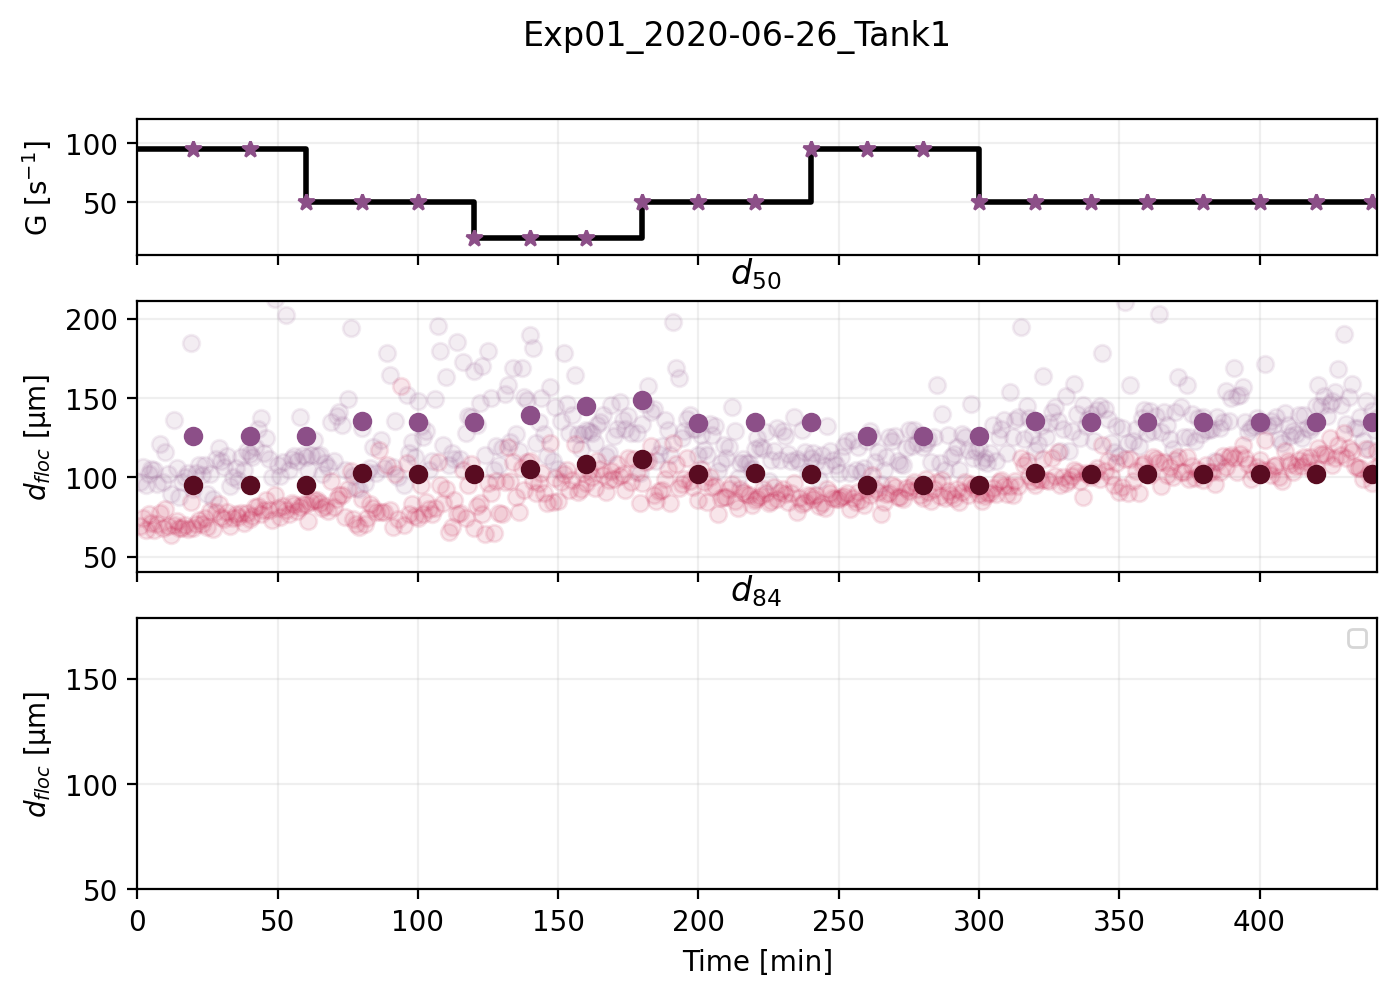

In [43]:
import pandas as pd 
import matplotlib.pyplot as plt

shapes = ['o', '^', '*', 's', 'D', 'P', 'X', 'h', 'H', 'v']

for experiment in experiments:

    fig = plt.figure(figsize=(8,5))

    gs = fig.add_gridspec(3,hspace=0.2, height_ratios=[0.5, 1,1])
    axs = gs.subplots(sharex=True, sharey=False)

    GS, obs, size  = get_files(experiment)

    xmin = 0
    xmax = GS['min'].iloc[-1]

    axs[0].plot(GS['time']/60, GS['G_Hz'], color="#000000", alpha=1, label='$G$', linewidth=2)
    axs[0].set_ylabel('G [$\mathrm{s^{-1}}$]')

    axs[0].set_xlim(xmin,xmax)
    axs[0].set_ylim(Gmin,Gmax)  

    if 'd84_mu' in size.columns:
        axs[1].plot(size['min_from_start'], size['d84_mu'],'o', color='#8C4F88', alpha=0.1,label='Abolfazli et al. 2024')
    axs[1].plot(size['min_from_start'], size['d50_mu'],'o', color='#BF0436', alpha=0.1,label='Abolfazli et al. 2024')
    axs[1].set_ylabel(r'$d_{\mathit{floc}}$ [µm]')
    axs[2].set_ylabel(r'$d_{\mathit{floc}}$ [µm]')
    axs[1].set_title("$d_{50}$ ")
    axs[2].set_title("$d_{84}$ ")
    axs[2].set_xlabel('Time [min]')
    axs[1].set_ylim(25,dmax)

    run_ids = get_runid(experiment)
    if len(run_ids) == 0:
        print('No runs found for %s. Skipping.' % experiment)
        plt.close()
        continue
    print("Run_IDs for %s: %s" % (experiment, run_ids))
    for ni,run_id in enumerate(run_ids):
        fn =  "output/%s.csv" % (run_id) 
        try: 
            model = pd.read_csv(fn) 
        except:
            continue
        parameters, label = get_parameters(run_id)

        axs[1].plot(model.time/60, model.d50, shapes[ni], color="#590C21", alpha=1)

        axs[1].plot(model.time/60, model.d84, shapes[ni], color='#8C4F88', alpha=1,label=label) #,label=label)

        axs[0].plot(model.time/60, model.g,'*', color='#8C4F88', alpha=1,label='$d_{84}$ (Modeled)')


    axs[1].set_ylim(40,max(model.d50)*1.9)
    axs[2].set_ylim(50,max(model.d84)*1.2)  
    for ax in axs:
        ax.grid(alpha=0.2)

    axs[2].legend(fontsize=8)
    plt.suptitle(experiment)
    assert(False)
    fig.savefig("validation/%s.png" % experiment, dpi=300, bbox_inches='tight')
    plt.close()

In [141]:
import pandas as pd 
import matplotlib.pyplot as plt

shapes = ['o', '^', '*', 's', 'D', 'P', 'X', 'h', 'H', 'v']

fig = plt.figure(figsize=(12,9))

gs = fig.add_gridspec(6, 3, hspace=0.4, height_ratios=[0.3, 1, 0.3, 1, 0.3, 1])
axs = gs.subplots(sharex=False, sharey=False)


experiments0 = [
    "Exp01_2020-06-26_Tank1",  "Exp02_2020-06-27_Tank1",   "Exp04_2020-06-29_Tank1", 
    "Exp06_2020-07-02_Tank1",   "Exp15_2021-01-10_Tank1", "Exp22_2021-01-11_Tank2",
    "Exp18_2021-01-14_Tank1",   "Exp05_2020-06-30_Tank1",    "Exp16_2021-01-11_Tank1", 
    "Exp10_2020-06-29_Tank2", 
    "Exp05_2020-06-30_Tank1",  "Exp11_2020-06-30_Tank2",  "Exp17_2021-01-13_Tank1",  "Exp23_2021-01-13_Tank2",
    "Exp12_2020-07-02_Tank2",  
]
for ie, experiment in enumerate(experiments0[0:9]):

    ix = ie // 3
    iy = ie % 3
    axs[2*ix + 1, iy].annotate(experiment, xy=(0.4, 0.05), xycoords='axes fraction', ha='right', fontsize=5,)


    GS, obs, size  = get_files(experiment)

    xmin = 0
    xmax = GS['min'].iloc[-1]

    axs[2*ix, iy].plot(GS['time']/60, GS['G_Hz'], color="#000000", alpha=1, label='$G$', linewidth=2)
    axs[2*ix, 0].set_ylabel('G [$\mathrm{s^{-1}}$]')

    axs[2*ix, iy].set_ylim(Gmin,Gmax)  

    if ie==0:
        axs[1,0].plot([], [], 'o', color='#8C4F88', alpha=0.99,label=r'$d_{84}$ (Abolfazli et al. 2024)')
        axs[1,0].plot([], [],'o', color='#BF0436', alpha=0.99, label=r'$d_{50}$ (Abolfazli et al. 2024)')
        # axs[0,1].legend(fontsize=7, loc='upper left')
        # axs[0,0].legend(fontsize=7, loc='upper left')
    if 'd84_mu' in size.columns:
        axs[2*ix+1, iy].plot(size['min_from_start'], size['d84_mu'],'o', color='#8C4F88', alpha=0.10) #,label=r'$d_{84}$ (Abolfazli et al. 2024)')
    axs[2*ix+1, iy].plot(size['min_from_start'], size['d50_mu'],'o', color='#BF0436', alpha=0.1) #,label=r'$d_{50}$ (Abolfazli et al. 2024)')

    
    axs[2*ix+1, 0].set_ylabel(r'$d_{\mathit{floc}}$ [µm]')
    # axs[2].set_ylabel(r'$d_{\mathit{floc}}$ [µm]')

    # axs[1, ie].set_xlabel('Time [min]')
    axs[2*ix+1, iy].set_ylim(25, dmax)

    run_ids = get_runid(experiment)
    if len(run_ids) == 0:
        print('No runs found for %s. Skipping.' % experiment)
        plt.close()
        continue
    print("Run_IDs for %s: %s" % (experiment, run_ids))
    for ni,run_id in enumerate(run_ids):
        fn =  "output/%s.csv" % (run_id) 
        try: 
            model = pd.read_csv(fn) 
        except:
            continue
        parameters, label = get_parameters(run_id)

        print(len(model.time))
        if len(model.time) > 34:
            axs[2*ix+1, iy].plot(model.time[::4]/60, model.d50[::4], shapes[ni], color="#590C21", alpha=1, label="Modeled $d_{50}$ %s" % label)
            axs[2*ix+1, iy].plot(model.time[::4]/60, model.d84[::4], shapes[ni], color='#8C4F88', alpha=1,label="Modeled $d_{84}$ %s" % label) #,label=label)

        else: 
            axs[2*ix+1, iy].plot(model.time[::1]/60, model.d50[::1], shapes[ni], color="#590C21", alpha=1, label="Modeled $d_{50}$ %s" % label)
            axs[2*ix+1, iy].plot(model.time[::1]/60, model.d84[::1], shapes[ni], color='#8C4F88', alpha=1,label="Modeled $d_{84}$ %s" % label) #,label=label)

    axs[2*ix, iy].set_xlim(0, max(model.time/60)+5)
    axs[2*ix + 1, iy].set_xlim(0, max(model.time/60)+5)
    axs[2*ix+1, iy].set_ylim(min(model.d50)*0.5,max(model.d84)*1.4)  
    axs[2*ix+1, iy].legend(fontsize=7, loc='upper right', ncol=1)
    axs[-1, iy].set_xlabel('Time [min]')
for ax in axs.flatten():
    ax.grid(alpha=0.2)
    ax.tick_params(axis='x', labelsize=7)
    ax.tick_params(axis='y', labelsize=7)
fig.savefig("validation/full_set.png", dpi=300, bbox_inches='tight')
plt.close()

<>:33: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:33: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_1415854/3951308283.py:33: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  axs[2*ix, 0].set_ylabel('G [$\mathrm{s^{-1}}$]')


Run_IDs for Exp01_2020-06-26_Tank1: [15033713440217902373]
22
Run_IDs for Exp02_2020-06-27_Tank1: [16627141910714009463]
22
Run_IDs for Exp04_2020-06-29_Tank1: [9459951407631413914]
35
Run_IDs for Exp06_2020-07-02_Tank1: [4817641501614416979]
15
Run_IDs for Exp15_2021-01-10_Tank1: [13761799527759793446]
56
Run_IDs for Exp22_2021-01-11_Tank2: [12364474097316649135]
57
Run_IDs for Exp18_2021-01-14_Tank1: [7976303935156369761]
16
Run_IDs for Exp05_2020-06-30_Tank1: [15658654732444425593]
40
Run_IDs for Exp16_2021-01-11_Tank1: [2228852274592523844]
56
